In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
# matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime

import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource
sys.path.append('../..')
import Utils

In [2]:
# 这个是看rsi大于80的情况下，涨跌幅的
codes = datasource.get_codes()
code = codes[0]
dt = datasource.get_data(code)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
date,,,,,,,,,,,,,
2010-01-04,sh.600000,5.079055,5.088362,4.923170,4.930150,5.046482,66191338,1.419984e+09,2,0.835129,1,-2.3052,0
2010-01-05,sh.600000,4.981336,5.020889,4.837085,4.967376,4.930150,115147943,2.436891e+09,2,1.452808,1,0.7551,0
2010-01-06,sh.600000,4.953417,4.955743,4.858024,4.869658,4.967376,96782575,2.034174e+09,2,1.221095,1,-1.9672,0
2010-01-07,sh.600000,4.858024,4.895251,4.723079,4.760305,4.869658,85236072,1.761801e+09,2,1.075414,1,-2.2456,0
2010-01-08,sh.600000,4.732386,4.839411,4.723079,4.813818,4.760305,65707646,1.349532e+09,2,0.829026,1,1.1241,0


In [3]:
# 这里volume上涨多少倍
N1 = 1.02
N2 = 1.5

dt['prevolume'] = dt['volume'].shift(1)
for i in range(5):
    dt[f'close{i+1}'] = dt['close'].shift(-(i+1))
    dt[f'rate{i+1}'] = (dt[f'close{i+1}']-dt['close'])/dt['close']*100
dt2 = dt.loc[(dt['close'] > N1 *  dt['preclose']) & (dt['prevolume'] > N2 * dt['volume']) ]
dt2.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,...,close1,rate1,close2,rate2,close3,rate3,close4,rate4,close5,rate5
date,,,,,,,,,,,,,,,,,,,,,
2014-11-25,sh.600000,5.094742,5.226706,5.066464,5.221993,5.118307,289490096,3.159162e+09,2,1.939921,...,5.335105,2.166065,5.410513,3.610108,5.844108,11.913357,5.730996,9.747292,6.065618,16.155235
2015-07-09,sh.600000,7.867497,8.582724,7.586339,8.360757,7.867497,545237280,8.927542e+09,2,3.653725,...,8.523533,1.946903,8.405150,0.530973,8.262105,-1.179941,8.419948,0.707965,8.365690,0.058997
2015-09-14,sh.600000,7.645530,7.867497,7.364372,7.857632,7.675126,183936607,2.836988e+09,2,1.232590,...,7.625800,-2.950408,7.611002,-3.138732,7.453159,-5.147520,7.413698,-5.649718,7.384102,-6.026365
2016-01-12,sh.600000,8.469274,8.641915,8.424881,8.607387,8.410083,55374454,9.640615e+08,2,0.296859,...,8.577791,-0.343840,8.839219,2.693410,8.671511,0.744986,8.720837,1.318052,8.765230,1.833811
2018-10-12,sh.600000,7.356631,7.505249,7.304614,7.453233,7.282321,25145127,2.508056e+08,2,0.089472,...,7.453233,0.000000,7.468095,0.199402,7.646437,2.592223,7.572128,1.595214,7.713316,3.489531


In [4]:
for i in range(5):
    _means = dt2[f'rate{i+1}'].mean()
    print(f'{i+1}:{_means}')

1:0.35638092174491
2:0.8025875102142704
3:1.4031931946213418
4:1.393189195302946
5:2.5131046315777317


In [5]:
COLUMNS = [f'rate{i+1}' for i in range(5)]
dt3 = dt2.loc[:, COLUMNS].mean().reset_index().rename(columns={0:'count'})
dt3.head()

,index,count
0,rate1,0.356381
1,rate2,0.802588
2,rate3,1.403193
3,rate4,1.393189
4,rate5,2.513105


<BarContainer object of 5 artists>

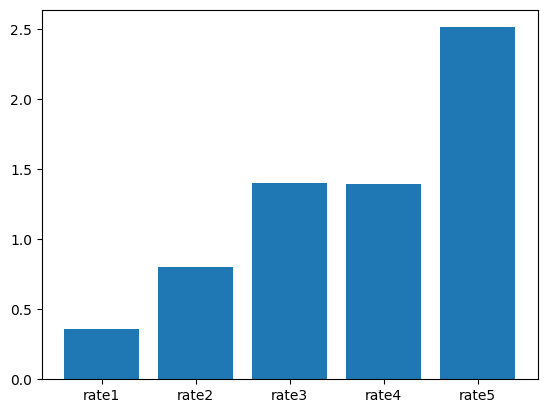

In [6]:
plt.bar(dt3['index'], dt3['count'])

# 用全部股市试试

In [7]:
# 这里volume上涨多少倍
N1 = 1.05
N2 = 2
COLUMNS = [f'rate{i+1}' for i in range(5)]
lst_rates = []
lst_dts = []
for i in tqdm(range(len(codes))):
    code = codes[i]
    dt = datasource.get_data(code)
    dt['prevolume'] = dt['volume'].shift(1)
    for i in range(5):
        dt[f'close{i+1}'] = dt['close'].shift(-(i+1))
        dt[f'rate{i+1}'] = (dt[f'close{i+1}']-dt['close'])/dt['close']*100
    dt2 = dt.loc[(dt['close'] > N1 *  dt['preclose']) & (dt['prevolume'] > N2 * dt['volume']) & (dt['close'] < 1.11 *  dt['preclose']) ]
    lst_dts.append(dt2) # 我想看看股市的图表
    dt3 = dt2.loc[:, COLUMNS].mean().reset_index().rename(columns={0:'count'})
    lst_rates.append(dt3)

100%|██████████████████████████████████████████████████████████████████████████████| 5493/5493 [04:09<00:00, 22.01it/s]


C:\Users\xuhen\AppData\Local\Temp\ipykernel_12052\1552933534.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dt_alls = pd.concat(lst_rates,  ignore_index=True).dropna().groupby(f'index').agg({'count':['mean','min','max','std']})


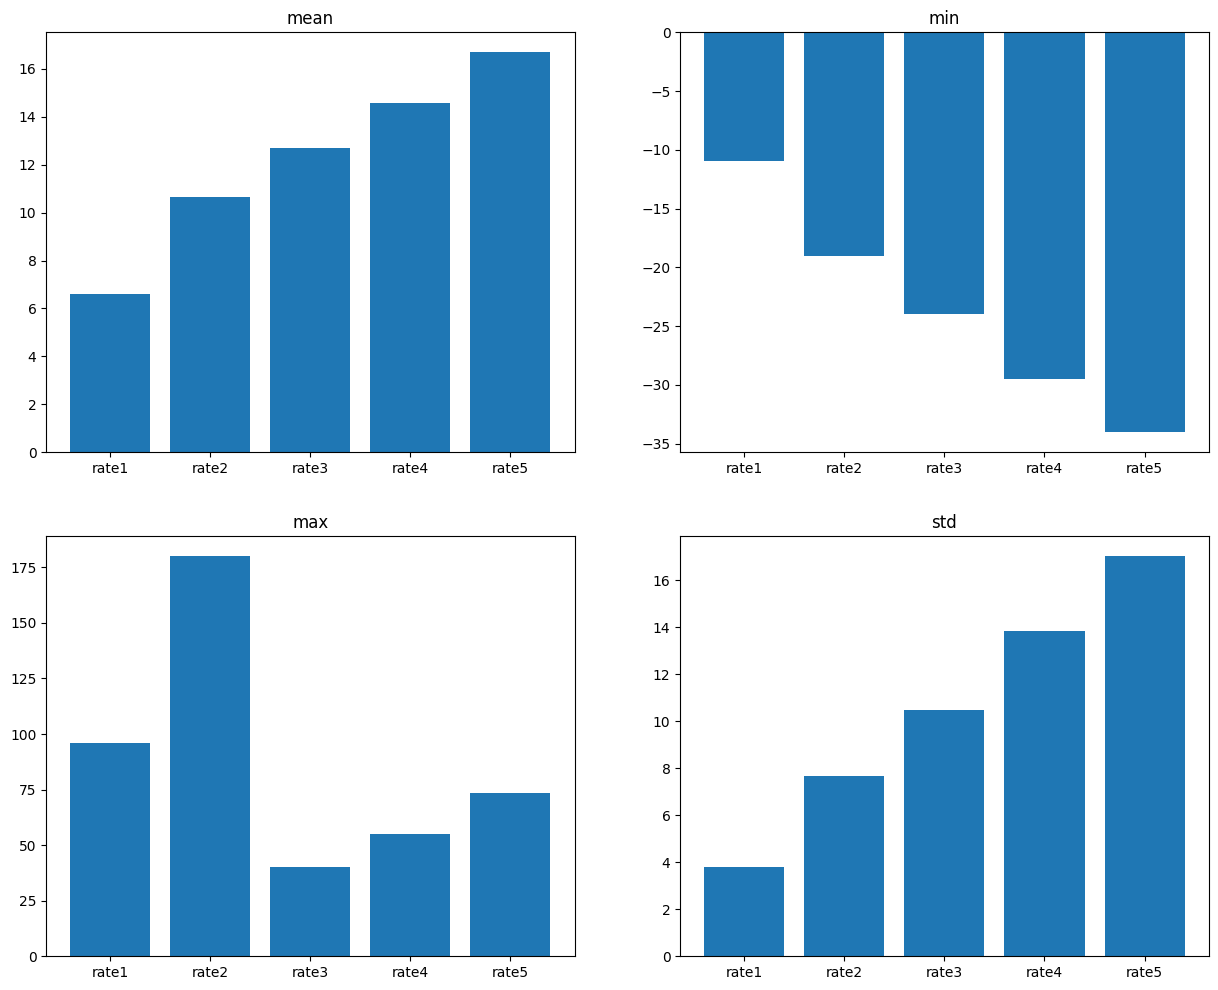

In [8]:
# 拼接
dt_alls = pd.concat(lst_rates,  ignore_index=True).dropna().groupby(f'index').agg({'count':['mean','min','max','std']})
# 这里需要整理后
COLUMNS2 = ['mean', 'min', 'max', 'std']
plt.figure(figsize=(15, 12))
for i in range(len(COLUMNS2)):
    plt.subplot(2, 2, i+1)
    plt.bar(dt_alls.index, dt_alls['count', COLUMNS2[i]])
    plt.title(COLUMNS2[i])

In [9]:
dt_alls.head()

count                                  
            mean        min         max        std
index                                             
rate1   6.594454 -10.930958   95.992321   3.780792
rate2  10.654638 -19.000000  179.977602   7.684511
rate3  12.709355 -24.000000   40.076794  10.488106
rate4  14.574463 -29.465649   55.091593  13.847673
rate5  16.690854 -34.041667   73.594112  17.015911

In [ ]:
# 这里看看图表
